<a target="_blank" href="https://storage.googleapis.com/weathernext-public/colabs/WeatherNext_3_Starter_Guide_Zarr_Spatial_Statistics_on_Google_Cloud_Storage.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Exploring Global Weather Forecasts with Zarr on Google Cloud Storage and WeatherNext 3

**Welcome!** This notebook demonstrates how to load, slice, and visualize a weather forecast dataset available in Zarr format on Google Cloud Storage, generated by Google DeepMind and Google Research's WeatherNext 3 model.

**Dataset Overview**

This dataset offers weather forecasts produced by WeatherNext 3, a state-of-the-art machine learning model developed by Google DeepMind and Google Research. It provides precomputed statistics over all 64 ensemble members of the forecasts for various weather variables, including temperature, precipitation, wind speed, and more, at a global scale and with a high degree of accuracy.

For individual ensemble forecasts, see the [Full Ensemble Zarr dataset](https://storage.googleapis.com/weathernext-public/colabs/WeatherNext_3_Starter_Guide_Zarr_Spatial_Full_Ensemble_on_Google_Cloud_Storage.ipynb).

**Notebook Purpose**

This notebook aims to:

* Familiarize users with the structure and content of the WeatherNext 3 weather forecast (statistics) dataset in Zarr.
* Demonstrate how to query and analyze this data using the Xarray library's powerful tools and functions.
* Showcase the potential applications of this data for various weather-related tasks, such as forecasting, climate analysis, and risk assessment.

**Copyright Information**

Copyright 2026 Google LLC.

All materials are licensed under the [Creative Commons Attribution 4.0 International License (CC-BY)](https://creativecommons.org/licenses/by/4.0/legalcode).

**Additional Documentation**

[Xarray Library Documentation](https://docs.xarray.dev)


## Import Python Libraries & Setup


In [ ]:
!pip install zarr obstore


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 101.3 MB/s eta 0:00:00


In [ ]:
from google.colab import auth
import folium
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import obstore
from scipy import interpolate as scipy_interpolate
import xarray as xr
import zarr

import warnings
# Suppress FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)


## Set Google Cloud Project ID


In [ ]:
project_id = '' #@param{type:"string"}


# Weather Forecast Dataset Schema (Spatial Statistics)

Spatial statistics are published in GCS under:
`gs://weathernext3_statistics_spatial/weathernext_3_0_0_statistics/zarr/2026_to_present/<YYYYMMDD_HHhr_XX_preds>/predictions.zarr/`

### Horizon
6-hour inits (00, 06, 12, 18 UTC): with a 360-hour horizon.

Interim 1-hour inits (01–05, 07–11, 13–17, 19–23 UTC): with a 48-hour horizon.


### Dimensions

<div class="inline-table">

| Dimension | Description | Typical Size |
| --- | --- | --- |
| `lat_0p05`, `lon_0p05` | High-resolution station grid (0.05°) | 3601 × 7200 |
| `lat_0p1`, `lon_0p1` | Fine grid (0.1°) | 1801 × 3600 |
| `lead_time` | Forecast lead time at 1-hour intervals (1h to 360h) | 360 or 48 |

</div>

### Coordinates

<div class="inline-table">

| Coordinate | Description | Type |
| --- | --- | --- |
| `datetime` | Valid forecast time for each lead time | `datetime64[ns]` |
| `init_time` | Forecast initialization timestamp | `datetime64[ns]` |

</div>

### Available Pre-Computed Statistics
Each variable provides the following statistical metrics:
* `<variable>_mean`: Ensemble mean
* `<variable>_p10`: 10th percentile
* `<variable>_p25`: 25th percentile
* `<variable>_p50`: 50th percentile (median)
* `<variable>_p75`: 75th percentile
* `<variable>_p90`: 90th percentile

### Surface & Single-Level Variables

<div class="inline-table">

| Base Name | Units | Grid | Description |
| --- | --- | --- | --- |
| `dewpoint_temperature_2m` | K | 0.1° | 2m dewpoint temperature |
| `experimental_tp_1hr` | m | 0.1° | Experimental precipitation rate |
| `high_cloud_cover` | [0-1] | 0.1° | High-altitude cloud cover |
| `imerg_tp_1hr` | m | 0.1° | IMERG precipitation rate |
| `low_cloud_cover` | [0-1] | 0.1° | Low-altitude cloud cover |
| `mean_sea_level_pressure` | Pa | 0.1° | Mean sea level pressure |
| `medium_cloud_cover` | [0-1] | 0.1° | Mid-altitude cloud cover |
| `sea_surface_temperature` | K | 0.1° | Sea surface temperature |
| `station_head_dewpoint_temperature_2m` | K | 0.05° | 2m dewpoint at station locations |
| `station_head_temperature_2m` | K | 0.05° | 2m temperature at station observation locations |
| `surface_solar_radiation_downwards_1hr` | J/m² | 0.1° | Surface solar radiation downwards |
| `temperature_2m` | K | 0.1° | 2m temperature |
| `total_cloud_cover` | [0-1] | 0.1° | Total cloud cover fraction |
| `total_precipitation_1hr` | m | 0.1° | 1-hour total precipitation |
| `total_sky_direct_solar_radiation_at_surface_1hr` | J/m² | 0.1° | Total sky direct solar radiation |
| `u_component_of_wind_100m` | m/s | 0.1° | 100m eastward wind |
| `u_component_of_wind_10m` | m/s | 0.1° | 10m eastward wind |
| `v_component_of_wind_100m` | m/s | 0.1° | 100m northward wind |
| `v_component_of_wind_10m` | m/s | 0.1° | 10m northward wind |
| `wind_speed_100m` | m/s | 0.1° | 100m wind speed |
| `wind_speed_10m` | m/s | 0.1° | 10m wind speed |

</div>

# Example Queries

First, open the spatial statistics Zarr dataset in GCS using `obstore` with Requester Pays credentials.


In [ ]:
auth.authenticate_user()

gcs_store = obstore.store.GCSStore(
    bucket="weathernext3_statistics_spatial",
    prefix="weathernext_3_0_0_statistics/zarr/2026_to_present/20260826_00hr_01_preds/predictions.zarr",
    # This is a Requester Pays bucket, so we pass in the billing project header.
    client_options={
        "default_headers": {
            "x-goog-user-project": project_id
        }
    })
zstore = zarr.storage.ObjectStore(gcs_store)

# Open the statistics Zarr dataset
ds = xr.open_zarr(zstore, chunks={})

# Show schema
ds


<xarray.Dataset> Size: 2TB
Dimensions:                                               (lead_time: 360,
                                                           lat_0p1: 1801,
                                                           lon_0p1: 3600,
                                                           lat_0p05: 3601,
                                                           lon_0p05: 7200)
Coordinates:
  * lead_time                                             (lead_time) timedelta64[ns] 3kB ...
  * lat_0p1                                               (lat_0p1) float32 7kB ...
  * lon_0p1                                               (lon_0p1) float32 14kB ...
  * lat_0p05                                              (lat_0p05) float32 14kB ...
  * lon_0p05                                              (lon_0p05) float32 29kB ...
    datetime                                              (lead_time) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    init_time                                             datetime64[ns] 8B ...
Data variables: (12/126)
    dewpoint_temperature_2m_mean                          (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>
    dewpoint_temperature_2m_p10                           (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>
    dewpoint_temperature_2m_p25                           (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>
    dewpoint_temperature_2m_p50                           (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>
    dewpoint_temperature_2m_p75                           (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>
    dewpoint_temperature_2m_p90                           (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>
    ...                                                    ...
    wind_speed_10m_mean                                   (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>
    wind_speed_10m_p10                                    (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>
    wind_speed_10m_p25                                    (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>
    wind_speed_10m_p50                                    (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>
    wind_speed_10m_p75                                    (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>
    wind_speed_10m_p90                                    (lead_time, lat_0p1, lon_0p1) float32 9GB dask.array<chunksize=(1, 1801, 3600), meta=np.ndarray>

## Exploring Temperature Forecasts for New York City - 24 Hour (Hourly)

This query retrieves hourly 2-meter temperature forecast statistics for New York, NY for the first 24 hours precomputed across all ensemble members for a specific initialization timestamp, using `station_head_temperature_2m` on the 0.05° grid.


In [ ]:
# Note: longitudes in this dataset use 0-360 range.
# Bounding box coordinates for New York City
min_lon, max_lon = 285.74, 286.30
min_lat, max_lat = 40.50, 40.90

# Select station head 2m temperature statistical metrics for the NYC region
temp_2m_vars = [
    'station_head_temperature_2m_mean',
    'station_head_temperature_2m_p10',
    'station_head_temperature_2m_p90'
]

nyc_ds = ds[temp_2m_vars].sel(
    lat_0p05=slice(min_lat, max_lat),
    lon_0p05=slice(min_lon, max_lon)
)

# Show schema for sliced dataset
nyc_ds


<xarray.Dataset> Size: 472kB
Dimensions:                           (lead_time: 360, lat_0p05: 9, lon_0p05: 12)
Coordinates:
  * lead_time                         (lead_time) timedelta64[ns] 3kB 01:00:0...
  * lat_0p05                          (lat_0p05) float32 36B 40.5 40.55 ... 40.9
  * lon_0p05                          (lon_0p05) float32 48B 285.8 ... 286.3
    datetime                          (lead_time) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    init_time                         datetime64[ns] 8B ...
Data variables:
    station_head_temperature_2m_mean  (lead_time, lat_0p05, lon_0p05) float32 156kB dask.array<chunksize=(1, 9, 12), meta=np.ndarray>
    station_head_temperature_2m_p10   (lead_time, lat_0p05, lon_0p05) float32 156kB dask.array<chunksize=(1, 9, 12), meta=np.ndarray>
    station_head_temperature_2m_p90   (lead_time, lat_0p05, lon_0p05) float32 156kB dask.array<chunksize=(1, 9, 12), meta=np.ndarray>

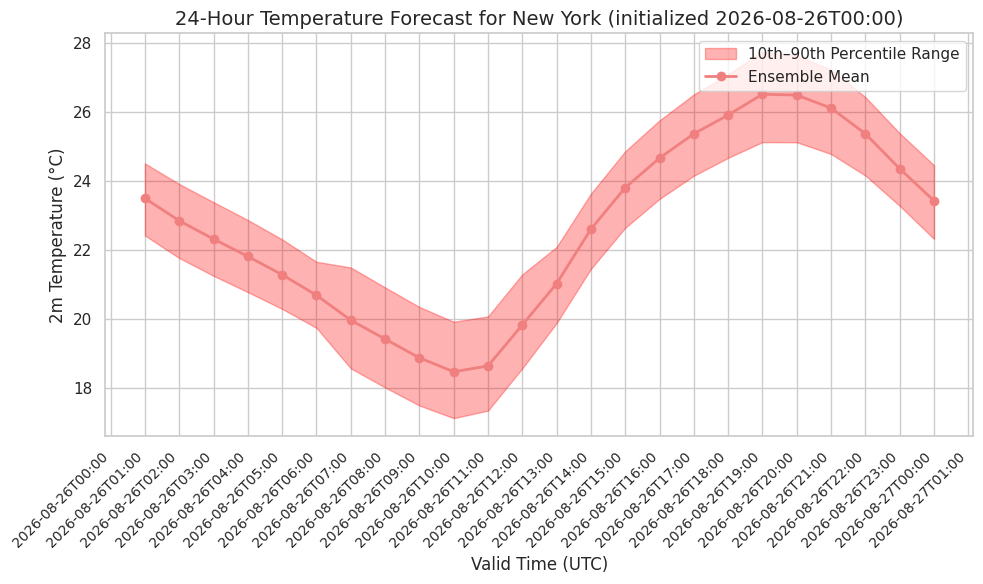

In [ ]:
# Generating this plot can take up to 5 minutes.

# Select lead times covering the first 24 hours (1h to 24h)
lead_times_24h = [np.timedelta64(h, 'h') for h in range(1, 25)]
nyc_24h = nyc_ds.sel(lead_time=lead_times_24h)

# Load data into memory once
nyc_24h = nyc_24h.load()

# Spatially average across the NYC bounding box and convert from Kelvin to Celsius
temp_2m_mean = nyc_24h['station_head_temperature_2m_mean'].mean(dim=('lat_0p05', 'lon_0p05')).values - 273.15
temp_2m_p10  = nyc_24h['station_head_temperature_2m_p10'].mean(dim=('lat_0p05', 'lon_0p05')).values - 273.15
temp_2m_p90  = nyc_24h['station_head_temperature_2m_p90'].mean(dim=('lat_0p05', 'lon_0p05')).values - 273.15

valid_times = nyc_24h['datetime'].values

# Set up the plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 10th to 90th percentile uncertainty band
plt.fill_between(valid_times, temp_2m_p10, temp_2m_p90, color='red', alpha=0.3, label='10th–90th Percentile Range')

# Pre-computed Ensemble Mean
plt.plot(valid_times, temp_2m_mean, color='lightcoral', marker='o', linewidth=2, label='Ensemble Mean')

# Labels and axes
plt.xlabel('Valid Time (UTC)', fontsize=12)
plt.ylabel('2m Temperature (°C)', fontsize=12)
# Programmatically determine the init_time in string format for the plot title
forecast_date = np.datetime_as_string(ds['init_time'].values, unit='m')
plt.title(f'24-Hour Temperature Forecast for New York (initialized {forecast_date})', fontsize=14)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%dT%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


## World - 08/26/2026 06:00 Hours

This example gets the precomputed statistical values for weather variables in a single forecast step (with an `init_time` of `2026-08-26 00:00:00 UTC` and valid forecast `datetime` of `2026-08-26 06:00:00 UTC`).


In [ ]:
# Select 6h lead time
world_stats = ds.sel(lead_time=np.timedelta64(6, 'h'))

world_stats


<xarray.Dataset> Size: 4GB
Dimensions:                                               (lat_0p1: 1801,
                                                           lon_0p1: 3600,
                                                           lat_0p05: 3601,
                                                           lon_0p05: 7200)
Coordinates:
  * lat_0p1                                               (lat_0p1) float32 7kB ...
  * lon_0p1                                               (lon_0p1) float32 14kB ...
  * lat_0p05                                              (lat_0p05) float32 14kB ...
  * lon_0p05                                              (lon_0p05) float32 29kB ...
    datetime                                              datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
    init_time                                             datetime64[ns] 8B 2...
    lead_time                                             timedelta64[ns] 8B ...
Data variables: (12/126)
    dewpoint_temperature_2m_mean                          (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>
    dewpoint_temperature_2m_p10                           (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>
    dewpoint_temperature_2m_p25                           (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>
    dewpoint_temperature_2m_p50                           (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>
    dewpoint_temperature_2m_p75                           (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>
    dewpoint_temperature_2m_p90                           (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>
    ...                                                    ...
    wind_speed_10m_mean                                   (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>
    wind_speed_10m_p10                                    (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>
    wind_speed_10m_p25                                    (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>
    wind_speed_10m_p50                                    (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>
    wind_speed_10m_p75                                    (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>
    wind_speed_10m_p90                                    (lat_0p1, lon_0p1) float32 26MB dask.array<chunksize=(1801, 3600), meta=np.ndarray>


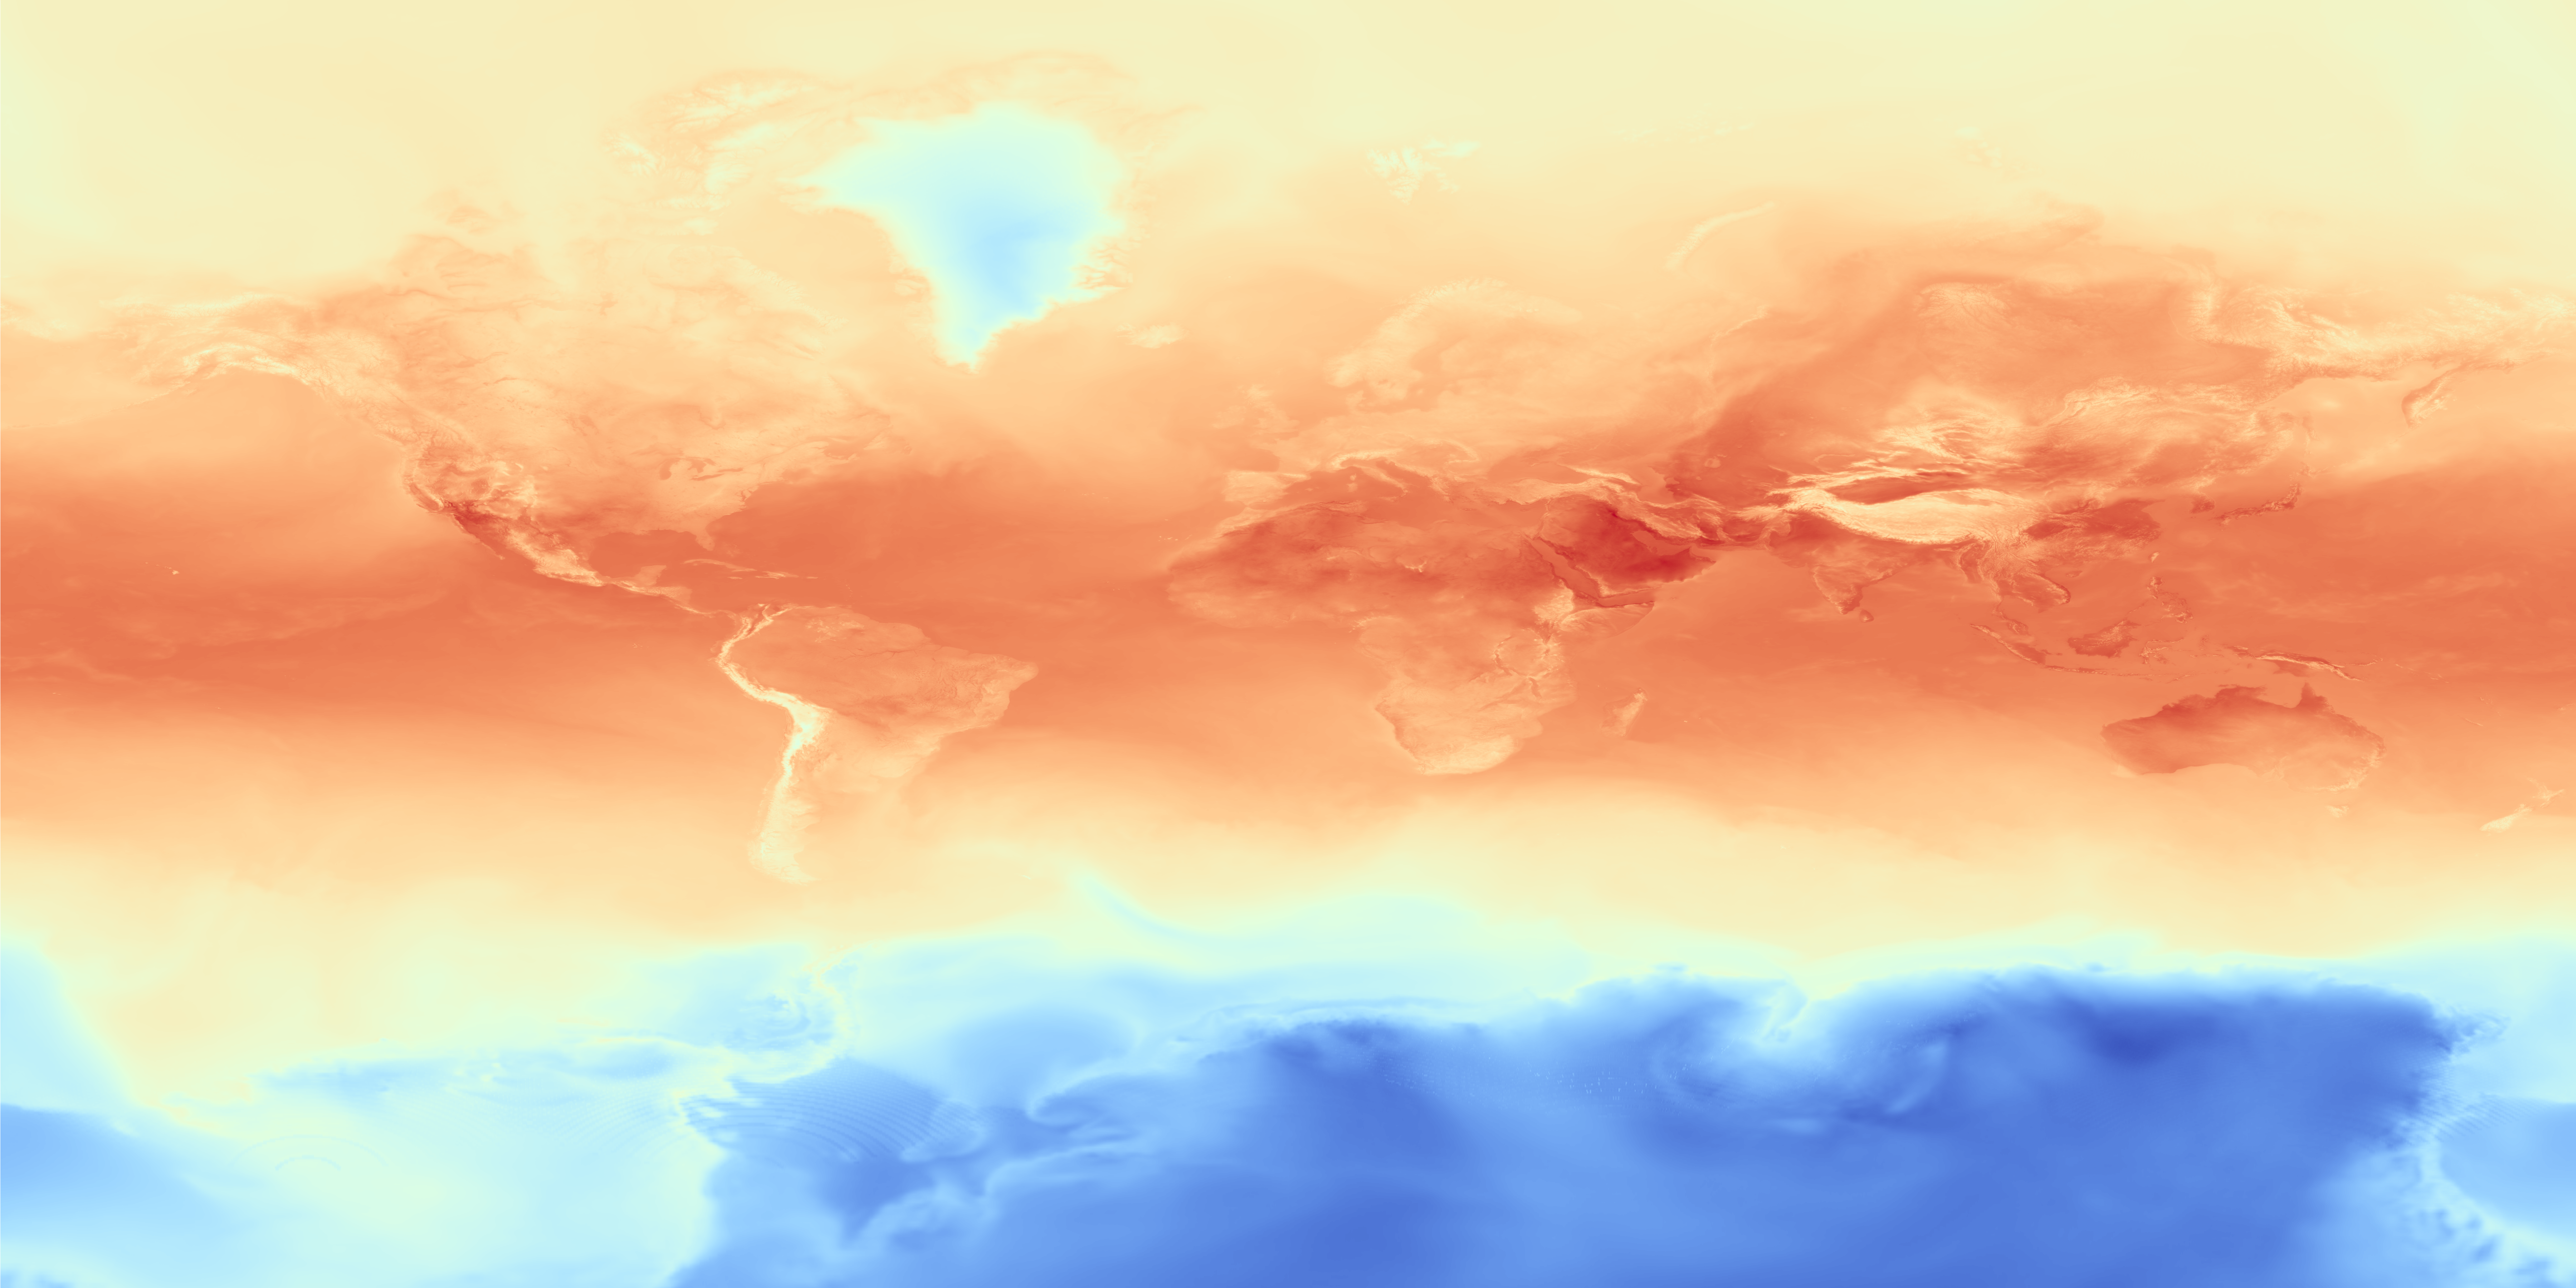

In [ ]:
# Map display options
variable = "station_head_temperature_2m_mean"  # @param ["dewpoint_temperature_2m_mean", "experimental_tp_1hr_mean", "high_cloud_cover_mean", "imerg_tp_1hr_mean", "low_cloud_cover_mean", "mean_sea_level_pressure_mean", "medium_cloud_cover_mean", "sea_surface_temperature_mean", "station_head_dewpoint_temperature_2m_mean", "station_head_temperature_2m_mean", "surface_solar_radiation_downwards_1hr_mean", "temperature_2m_mean", "total_cloud_cover_mean", "total_precipitation_1hr_mean", "total_sky_direct_solar_radiation_at_surface_1hr_mean", "u_component_of_wind_100m_mean", "u_component_of_wind_10m_mean", "v_component_of_wind_100m_mean", "v_component_of_wind_10m_mean", "wind_speed_100m_mean", "wind_speed_10m_mean"]
palette = "coolwarm"  # @param ["viridis", "coolwarm", "Spectral_r", "turbo", "BuPu"]

var_stats = world_stats[variable]

# Identify spatial dimensions for the specific variable
if "lat_0p05" in var_stats.dims:
  y_dim, x_dim = "lat_0p05", "lon_0p05"
else:
  y_dim, x_dim = "lat_0p1", "lon_0p1"

# Get lat, lon, and variable values as 1d arrays
var_flat = var_stats.stack(lat_lon=(y_dim, x_dim))
x = var_flat[x_dim].values
y = var_flat[y_dim].values
z = var_flat.values

# Convert longitudes from [0, 360) to [-180, 180] for Web Mercator mapping
x = np.where(x > 180, x - 360, x)

nx = var_stats.sizes[x_dim]
ny = var_stats.sizes[y_dim]

# Shift bin edges by half a cell so grid points sit at the center of each bin
dx = 360.0 / nx
dy = 180.0 / ny
lon_bins = np.linspace(-180.0 - dx / 2, 180.0 - dx / 2, nx + 1)
lat_bins = np.linspace(-90.0 - dy / 2, 90.0 + dy / 2, ny + 1)

# Bin data onto the regular grid
weighted_sum, _, _ = np.histogram2d(x, y, bins=(lon_bins, lat_bins), weights=z)
counts, _, _ = np.histogram2d(x, y, bins=(lon_bins, lat_bins))

with np.errstate(divide='ignore', invalid='ignore'):
  grid = np.where(counts > 0, weighted_sum / counts, np.nan)

# Transpose and flip so row 0 is North (+90) and col 0 is West (-180)
grid_equirectangular = np.flipud(grid.T)

# Reproject equirectangular latitudes to Web Mercator latitudes (EPSG:3857)
max_merc_lat = 85.0511287798
y_merc = np.linspace(np.pi, -np.pi, ny)
lat_target = np.degrees(2 * np.arctan(np.exp(y_merc)) - np.pi / 2)
lat_source = np.linspace(90.0, -90.0, ny)

# 1D interpolation along the latitude axis
f_interp = scipy_interpolate.interp1d(
    lat_source,
    grid_equirectangular,
    axis=0,
    kind='linear',
    bounds_error=False,
    fill_value=np.nan,
)
grid_mercator = f_interp(lat_target)

# Normalize data for colormapping
vmin, vmax = np.nanmin(grid_mercator), np.nanmax(grid_mercator)
norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
cm = matplotlib.colormaps[palette]
rgba_img = cm(norm(grid_mercator))

# Create a base map
m = folium.Map(location=[30, 0], zoom_start=2)

# Add seamless raster overlay aligned with Web Mercator bounds
folium.raster_layers.ImageOverlay(
    image=rgba_img,
    bounds=[[-max_merc_lat, -180.0], [max_merc_lat, 180.0]],
    mercator_project=False,
    opacity=0.5,
).add_to(m)

# Display the map
m